# B07a · Generate a predictor from a table

**Skill:** trace support→generated parameters→query prediction and count the complete serving cost.

PROVIDED exposes the full released HyperFast architecture, optional downstream optimizer and course inference loop. TODO contains 3 live functions; CHECK gives immediate hand-computed feedback; EXIT requires a written defense. Tier-A real data: banknote, phoneme and diabetes. The archive includes authenticated saved evidence for offline audit. Fresh execution additionally needs the 5.09 GB original checkpoint; no paid service is required. Live Colab NOT_CHECKED.

## Concept recap
A support row includes a known label; a query does not. A hypernetwork hθ generates weights φ=hθ(S) for another network fφ. Meta-training learns θ across tasks. Generating φ with frozen θ is adaptation without an optimizer. The produced MLP applies matrix multiplications, biases and ReLU (negative→zero). Softmax turns output logits into class probabilities.

A pure generated predictor can retain only its preprocessing and parameters. HyperFast's optional nearest-neighbor correction and iLTM's retrieval still require support. MotherNet uses a support transformer and low-rank child factors; HyperFast uses feedforward modules over RF/PCA features; iLTM adds tree/robust embeddings and cosine-weighted context. They are not interchangeable inference paths.

**Predict before coding:** must retrieval improve every split? Does one forward pass eliminate pretraining cost?


## Model architecture · mothernet

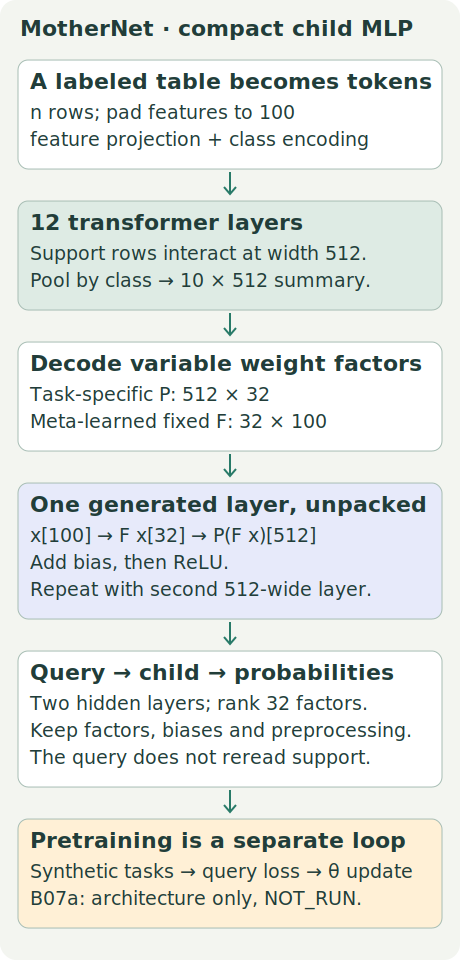

MotherNet v2: class-pooled transformer output generates rank32 factors for a two-hidden-layer child. Fixed factors were learned during meta-training. Architecture only.

## Model architecture · hyperfast

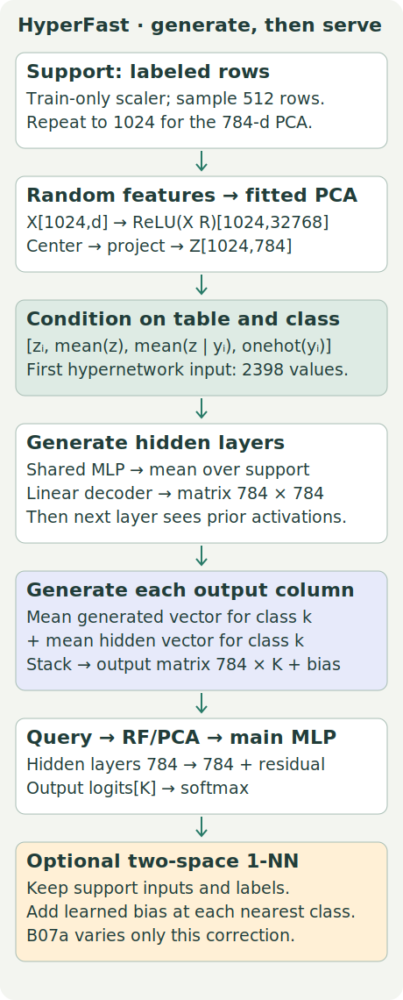

Full released HyperFast path: 1024 repeated support rows, 32768 random features, 784 PCA coordinates and generated layers. Retrieval retains support.

## Model architecture · iltm

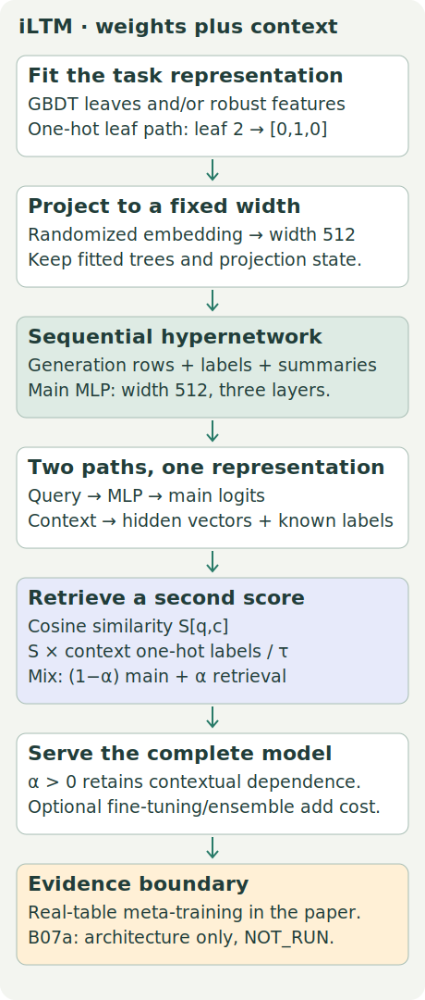

iLTM paper path: fitted tree/robust features, fixed-size projection, generated MLP and optional cosine-weighted context. Architecture only.

## Worked trace and experiment contract
Class0 generated rows[1,2,.1],[3,4,.3] average to[2,3,.2]. Hidden rows[2,0],[0,2] average to[1,1]. Add only to the first2coordinates→[3,4,.2]. Class1 gives[6,7,.5]. Query hidden[1,2] yields logits[11.2,20.5]. A nearest-class 0 correction10 reverses the winner. These are illustrative values, not checkpoint outputs.

Full released dimensions: 32768 random features→784PCA coordinates; two784-wide hidden layers and class output. The generated RF/PCA transformation is reused on queries. Support summaries condition each successive layer. Three full datasets×three fresh 80/20 seeds×retrieval off/on;18 arms share 9 generated predictors. Scaler fits all training rows; 512 sampled rows repeat to 1024 for PCA. No tuning, ensembles or fine-tuning. A tenth construction measures one banknote support refresh only. Timing 1/32/128 query rows, one warm-up and 3 repeats/seed, one CPU thread; retrieval recomputes support hidden vectors like the release.

Balanced accuracy=(recall0+recall1)/2. Log loss=mean(−log probability of true class). Sample SD over3splits is not a confidence interval. The original Table7 target uses 10 mini-test repetitions with a 300 s budget and is a separate source-gated experiment.


In [ ]:
# @colab-bootstrap: install missing dependencies; report version drift.
import importlib.util,importlib.metadata,subprocess,sys,warnings,os
versions={'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'scikit-learn': '1.9.0', 'scipy': '1.18.0'}
for module,package in [('numpy','numpy'),('pandas','pandas'),('torch','torch'),('sklearn','scikit-learn'),('scipy','scipy'),('requests','requests')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable,'-m','pip','install',package+('=='+versions[package] if package in versions else '')])
    elif package in versions and importlib.metadata.version(package)!=versions[package]:warnings.warn(package+' version differs; inspect parity')
import ast,base64,hashlib,io,json,math,statistics,zipfile,tempfile,time,gc,random
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)


In [ ]:
payload='...'
raw=base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest()=='4093c974e565bd0a0005ee8143d9efda7112eb6200608be067ac6a87424aac02'
workspace=Path(tempfile.mkdtemp(prefix='b07a-portable-'))
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    assert all(not Path(n).is_absolute() and '..' not in Path(n).parts for n in z.namelist())
    z.extractall(workspace)
lab=workspace/'labs';evidence=lab/'evidence/b07a'
print('Portable evidence/source package authenticated; checkpoint excluded')

## TODO · class_weights

Group support rows by class. Average generated vectors and add mean main-hidden activations to weight coordinates only. Return(hidden+1,classes). Preserve the input tensors. Match the release fallback to the global mean for an absent class.

In [ ]:
def class_weights(per_sample, hidden, labels, n_classes):
    raise NotImplementedError("TODO: class_weights")

In [ ]:
def check_class_weights(fn):
    p=torch.tensor([[1.,2.,.1],[3.,4.,.3],[5.,6.,.5]])
    h=torch.tensor([[2.,0.],[0.,2.],[1.,1.]])
    y=torch.tensor([0,0,1]);before=p.clone()
    expected=torch.tensor([[3.,6.,4.],[4.,7.,5.],[.2,.5,.3]])
    torch.testing.assert_close(fn(p,h,y,3),expected)
    torch.testing.assert_close(p,before)
    order=torch.tensor([2,0,1]);torch.testing.assert_close(fn(p[order],h[order],y[order],3),expected)
check_class_weights(class_weights)
print("CHECK passed")

## TODO · retrieval_bias

Compute Euclidean nearest-support classes in blocks of128query rows. First support index wins ties. Add the given amount to each matched class in a copied logit matrix. Query labels are not an argument.

In [ ]:
def retrieval_bias(logits, query, support, labels, amount):
    raise NotImplementedError("TODO: retrieval_bias")

In [ ]:
def check_retrieval(fn):
    logits=torch.tensor([[1.,2.],[4.,1.],[0.,0.]])
    query=torch.tensor([[0.,0.],[2.,2.],[1.,0.]])
    support=torch.tensor([[0.,0.],[2.,0.],[2.,2.]])
    labels=torch.tensor([0,1,1]);before=logits.clone()
    out=fn(logits,query,support,labels,torch.tensor(.75))
    torch.testing.assert_close(out,torch.tensor([[1.75,2.],[4.,1.75],[.75,0.]]))
    torch.testing.assert_close(logits,before)
check_retrieval(retrieval_bias)
print("CHECK passed")

## TODO · break_even

Return the first nonnegative integer query count where A is strictly cheaper, or None. Both methods rebuild refreshes+1times. Reject negative/nonfinite costs. Explain the difference between a tie and strict savings.

In [ ]:
def break_even(build_a, per_a, build_b, per_b, refreshes=0):
    raise NotImplementedError("TODO: break_even")

In [ ]:
def check_break_even(fn):
    assert fn(2,.001,0,.005)==501,'Strictly cheaper requires501 queries, not500'
    assert fn(2,.001,0,.005,refreshes=2)==1501
    assert fn(0,.001,2,.001)==0
    assert fn(2,.005,0,.001) is None
    assert fn(0,.005,2,.001)==0
    for args in [(-1,0,0,0),(1,float('nan'),0,1),(1,1,1,1,-1)]:
        try:fn(*args)
        except ValueError:pass
        else:raise AssertionError('Invalid costs accepted')
check_break_even(break_even)
print("CHECK passed")

## PROVIDED · RF/PCA support transformation

Full SVD produces deterministic-sign PCA coordinates. Transform uses the fitted mean and components. Random feature projection is created inside the generator.

In [ ]:
def seed_everything(seed: int):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_num_threads(1)

def svd_flip(u, v, u_based_decision=True):
    """Sign correction to ensure deterministic output from SVD.

    Adjusts the columns of u and the rows of v such that the loadings in the
    columns in u that are largest in absolute value are always positive.
    """
    if u_based_decision:
        # columns of u, rows of v
        max_abs_cols = torch.argmax(torch.abs(u), axis=0)
        signs = torch.sign(u[max_abs_cols, range(u.shape[1])])
        u *= signs
        v *= signs[:, None]
    else:
        # rows of v, columns of u
        max_abs_rows = torch.argmax(torch.abs(v), axis=1)
        signs = torch.sign(v[range(v.shape[0]), max_abs_rows])
        u *= signs
        v *= signs[:, None]

    return u, v

class TorchPCA:
    def __init__(self, n_components=None, fit="full"):
        self.n_components = n_components
        self.fit = fit

    def _fit(self, X):
        if self.n_components is None:
            n_components = min(X.shape)
        else:
            n_components = self.n_components

        n_samples, n_features = X.shape
        if n_components > min(X.shape):
            raise ValueError(
                f"n_components should be <= min(n_samples: {n_samples}, n_features: {n_features})"
            )

        self.mean_ = torch.mean(X, axis=0)
        X -= self.mean_

        if self.fit == "full":
            U, S, Vt = torch.linalg.svd(X, full_matrices=False)
            # flip eigenvectors' sign to enforce deterministic output
            U, Vt = svd_flip(U, Vt)
        elif self.fit == "lowrank":
            U, S, Vt = torch.pca_lowrank(X)

        self.components_ = Vt[:n_components]
        self.n_components_ = n_components

        return U, S, Vt

    def fit(self, X):
        self._fit(X)
        return self

    def transform(self, X):
        assert self.mean_ is not None
        X -= self.mean_
        return torch.matmul(X, self.components_.T)

    def fit_transform(self, X):
        U, S, Vt = self._fit(X)
        U = U[:, : self.n_components_]
        U *= S[: self.n_components_]
        return U

## PROVIDED · Complete released weight generator

Follow the1024support rows through means,46label slots and sequential layers. The final output calls your class_weights. Full dimensions remain unchanged.

In [ ]:
def get_main_weights(x, hn, weight_gen=None):
    emb = hn(x)
    if weight_gen is not None:
        global_emb = torch.mean(emb, dim=0)
        w = weight_gen(global_emb)
    else:
        w = emb
    return w

def forward_linear_layer(x, w, hs):
    w = w.view(-1, hs)
    m = w[:-1, :]
    b = w[-1, :]
    x = torch.mm(x, m) + b
    return x, (m, b)

class HyperFast(nn.Module):
    def __init__(self, cfg, head_fn=class_weights):
        super().__init__()
        self.head_fn = head_fn
        self.n_dims = cfg.n_dims
        self.max_categories = cfg.max_categories
        self.rf_size = cfg.rf_size
        self.torch_pca = cfg.torch_pca
        self.clip_data_value = cfg.clip_data_value
        self.hn_n_layers = cfg.hn_n_layers
        self.hn_hidden_size = cfg.hn_hidden_size
        self.main_n_layers = cfg.main_n_layers

        middle_layers = []
        for n in range(self.hn_n_layers - 2):
            middle_layers.append(nn.Linear(self.hn_hidden_size, self.hn_hidden_size))
            middle_layers.append(nn.ReLU())
        self.num_input_features_hn = self.n_dims + self.max_categories

        self.hypernetworks = nn.ModuleList()
        self.hn_emb_to_weights = nn.ModuleList()

        for n in range(self.main_n_layers - 1):
            if n > 0:
                self.num_input_features_hn = self.n_dims * 2 + self.max_categories
            num_input_features_hn = self.num_input_features_hn + self.n_dims * 2

            hn_layers = []
            hn_layers.append(nn.Linear(num_input_features_hn, self.hn_hidden_size))
            hn_layers.append(nn.ReLU())
            hn_layers = hn_layers + middle_layers

            self.hypernetworks.append(nn.Sequential(*hn_layers))
            self.output_size_hn = (self.n_dims + 1) * self.n_dims
            self.hn_emb_to_weights.append(
                nn.Linear(self.hn_hidden_size, self.output_size_hn)
            )

        hn_layers = []
        last_hn_output_size = self.n_dims + 1
        self.num_input_features_hn += self.n_dims * 2

        hn_layers.append(nn.Linear(self.num_input_features_hn, self.hn_hidden_size))
        hn_layers.append(nn.ReLU())
        hn_layers = hn_layers + middle_layers
        hn_layers.append(nn.Linear(self.hn_hidden_size, last_hn_output_size))
        self.hypernetworks.append(nn.Sequential(*hn_layers))
        self.nn_bias = nn.Parameter(torch.ones(2))

    def forward(self, X, y, n_classes):
        X = X.flatten(start_dim=1)
        rf_linear = nn.Linear(X.shape[1], self.rf_size, bias=False)
        nn.init.kaiming_normal_(rf_linear.weight, mode="fan_out", nonlinearity="relu")
        rf_linear.weight.requires_grad = False
        rf = nn.Sequential(rf_linear, nn.ReLU()).to(X.device)
        with torch.no_grad():
            X = rf(X)
        if self.torch_pca:
            self.pca = TorchPCA(n_components=self.n_dims)
        else:
            self.pca = PCA(n_components=self.n_dims)
        if self.torch_pca:
            X = self.pca.fit_transform(X)
        else:
            X = torch.from_numpy(self.pca.fit_transform(X.cpu().numpy())).to(X.device)
        X = torch.clamp(X, -self.clip_data_value, self.clip_data_value)

        out = X
        pca_global_mean = torch.mean(out, axis=0)
        pca_perclass_mean = []
        for lab in range(n_classes):
            if torch.sum((y == lab)) > 0:
                class_mean = torch.mean(out[y == lab], dim=0, keepdim=True)
            else:
                class_mean = torch.mean(out, dim=0, keepdim=True)
            pca_perclass_mean.append(class_mean)
        pca_perclass_mean = torch.cat(pca_perclass_mean)

        pca_concat = []
        for ii, lab in enumerate(y):
            if pca_perclass_mean.ndim == 1:
                pca_perclass_mean = pca_perclass_mean.unsqueeze(0)
            if out.ndim == 1:
                out = out.unsqueeze(0)

            lab_index = lab.item() if torch.is_tensor(lab) else lab
            lab_index = min(lab_index, pca_perclass_mean.size(0) - 1)

            row = torch.cat((out[ii], pca_global_mean, pca_perclass_mean[lab_index]))
            pca_concat.append(row)
        pca_output = torch.vstack(pca_concat)
        y_onehot = F.one_hot(y, self.max_categories)

        main_network = []
        for n in range(self.main_n_layers - 1):
            if n > 0:
                data = torch.cat((out, pca_output, y_onehot), dim=1)
            else:
                data = torch.cat((pca_output, y_onehot), dim=1)
            if n % 2 == 0:
                residual_connection = out

            weights = get_main_weights(
                data, self.hypernetworks[n], self.hn_emb_to_weights[n]
            )
            out, main_linear_layer = forward_linear_layer(out, weights, self.n_dims)
            if n % 2 == 0:
                out = F.relu(out)
            else:
                out = out + residual_connection
                out = F.relu(out)
            main_network.append(main_linear_layer)
        data = torch.cat((out, pca_output, y_onehot), dim=1)
        weights_per_sample = get_main_weights(data, self.hypernetworks[-1])

        weights = self.head_fn(weights_per_sample, out, y, n_classes)
        out, last_linear_layer = forward_linear_layer(out, weights, n_classes)
        main_network.append(last_linear_layer)

        return rf, self.pca, main_network, self.nn_bias

## PROVIDED · Main network and original neighbor mechanics

The residual connects the input of the hidden pair to its second output. Original nearest-neighbor helpers are visible for comparison; the course adapter uses your live retrieval_bias. The paper ablation labels the first correction as PCA-based; both archived wrappers use standardized original inputs. This course follows the released code.

In [ ]:
def nn_bias_logits(
    test_logits, test_samples, train_samples, train_labels, bias_param, n_classes, mini_batches
):
    with torch.no_grad():
        nn = NN(train_samples, train_labels)
        preds = nn.predict(test_samples, mini_batches=mini_batches)
        preds_onehot = F.one_hot(preds, n_classes)
    test_logits[preds_onehot.bool()] += bias_param
    return test_logits

def forward_main_network(x, main_network):
    for n, layer in enumerate(main_network):
        if n % 2 == 0:
            residual_connection = x
        matrix, bias = layer
        x = torch.mm(x, matrix) + bias
        if n % 2 == 1 and n != len(main_network) - 1:
            x = x + residual_connection

        if n != len(main_network) - 1:
            x = F.relu(x)
            if n == len(main_network) - 2:
                intermediate_activations = x
    return x, intermediate_activations

def transform_data_for_main_network(X, cfg, rf, pca):
    with torch.no_grad():
        X = rf(X)
    if cfg.torch_pca:
        X = pca.transform(X)
    else:
        X = torch.from_numpy(pca.transform(X.cpu().numpy())).to(cfg.device)
    X = torch.clamp(X, -cfg.clip_data_value, cfg.clip_data_value)
    return X

def distance_matrix(x, y=None, p=2):
    y = x if y is None else y

    n = x.size(0)
    m = y.size(0)
    d = x.size(1)

    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)

    dist = (
        torch.linalg.vector_norm(x - y, p, 2)
        if torch.__version__ >= "1.7.0"
        else torch.pow(x - y, p).sum(2) ** (1 / p)
    )

    return dist

class NN:
    def __init__(self, X=None, Y=None, p=2):
        self.p = p
        self.train(X, Y)

    def train(self, X, Y):
        self.train_pts = X
        self.train_label = Y

    def predict(self, x, mini_batches=True):
        if self.train_pts is None or self.train_label is None:
            name = self.__class__.__name__
            raise RuntimeError(
                f"{name} wasn't trained. Need to execute {name}.train() first"
            )

        if not mini_batches:
            with torch.no_grad():
                dist = distance_matrix(x, self.train_pts, self.p)
                labels = torch.argmin(dist, dim=1)
        else:
            with torch.no_grad():
                batch_size = 128
                num_batches = math.ceil(x.shape[0] / batch_size)
                labels = []
                for ii in range(num_batches):
                    x_ = x[batch_size * ii:batch_size * (ii + 1), :]
                    dist = distance_matrix(x_, self.train_pts, self.p)
                    labels_ = torch.argmin(dist, dim=1)
                    labels.append(labels_)
                labels = torch.cat(labels)

        return self.train_label[labels]

    def predict_from_training_with_LOO(self, mini_batches=True):
        if self.train_pts is None or self.train_label is None:
            name = self.__class__.__name__
            raise RuntimeError(
                f"{name} wasn't trained. Need to execute {name}.train() first"
            )

        if not mini_batches:
            dist = distance_matrix(self.train_pts, self.train_pts, self.p)
            dist.fill_diagonal_(float("inf"))
            labels = torch.argmin(dist, dim=1)
        else:
            batch_size = 128
            num_batches = math.ceil(self.train_pts.shape[0] / batch_size)
            labels = []
            for ii in range(num_batches):
                x_ = self.train_pts[batch_size * ii:batch_size * (ii + 1), :]
                dist = distance_matrix(x_, self.train_pts, self.p)
                dist.fill_diagonal_(float("inf"))
                labels_ = torch.argmin(dist, dim=1)
                labels.append(labels_)
            labels = torch.cat(labels)

        return self.train_label[labels]

## PROVIDED · Optional released downstream optimizer — NOT_RUN

Included to make the full release inspectable. This AdamW loop fine-tunes a task model; it is not the missing meta-training loop and is not called by this experiment.

In [ ]:
class MainNetworkTrainable(nn.Module):
    def __init__(self, cfg, n_classes, rf, pca, main_network, nn_bias):
        super(MainNetworkTrainable, self).__init__()
        self.cfg = cfg
        self.n_classes = n_classes
        self.pca = pca
        self.clip_data_value = cfg.clip_data_value
        self.main_network = main_network
        self.nn_bias = nn_bias
        self.use_nn_bias = cfg.nn_bias
        self.device = cfg.device

        self.rf = rf
        self.rf[0].weight.requires_grad = True
        self.pca_mean = (
            nn.Parameter(pca.mean_)
            if cfg.torch_pca
            else nn.Parameter(torch.from_numpy(pca.mean_))
        )
        self.input_features, self.output_features = pca.components_.shape
        self.pca_components = nn.Linear(
            self.input_features, self.output_features, bias=False
        )
        self.pca_components.weight = (
            nn.Parameter(pca.components_)
            if cfg.torch_pca
            else nn.Parameter(torch.from_numpy(pca.components_))
        )

        self.layers = nn.ModuleList()
        for matrix, bias in main_network:
            linear_layer = nn.Linear(matrix.shape[0], matrix.shape[1])
            linear_layer.weight = nn.Parameter(matrix.T)
            linear_layer.bias = nn.Parameter(bias)
            self.layers.append(linear_layer)

    def forward(self, X, y=None):
        intermediate_activations = [X]
        X = self.rf(X)
        X = X - self.pca_mean
        X = self.pca_components(X)
        X = torch.clamp(X, -self.clip_data_value, self.clip_data_value)

        for n, layer in enumerate(self.layers):
            if n % 2 == 0:
                residual_connection = X

            X = layer(X)
            if n % 2 == 1 and n < len(self.layers) - 1:
                X = X + residual_connection

            if n < len(self.layers) - 1:
                X = F.relu(X)
                if n == len(self.layers) - 2:
                    intermediate_activations.append(X)

        if self.use_nn_bias:
            assert y is not None
            for ii, bias in enumerate(self.nn_bias):
                nn = NN(intermediate_activations[ii], y)
                preds = nn.predict_from_training_with_LOO()
                preds_onehot = F.one_hot(preds, self.n_classes)
                X[preds_onehot.bool()] += bias
        return X

    def get_main_network_parts(self):
        rf_reconstructed = self.rf
        rf_reconstructed[0].weight.requires_grad = False

        pca_reconstructed = self.pca
        pca_reconstructed.mean_ = (
            self.pca_mean.detach()
            if self.cfg.torch_pca
            else self.pca_mean.cpu().detach().numpy()
        )
        pca_reconstructed.components_ = (
            self.pca_components.weight.detach()
            if self.cfg.torch_pca
            else self.pca_components.weight.cpu().detach().numpy()
        )

        main_network_reconstructed = []

        for layer in self.layers:
            weight_matrix = layer.weight.data.T
            bias_vector = layer.bias.data
            main_network_reconstructed.append((weight_matrix, bias_vector))

        return (
            rf_reconstructed,
            pca_reconstructed,
            main_network_reconstructed,
            self.nn_bias,
        )

def fine_tune_main_network(
    cfg,
    X,
    y,
    n_classes,
    rf,
    pca,
    main_network_layers,
    nn_bias,
    device,
    optimize_steps,
    batch_size,
):
    main_model = MainNetworkTrainable(
        cfg, n_classes, rf, pca, main_network_layers, nn_bias
    ).to(device)
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(main_model.parameters(), lr=cfg.lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.1, patience=10
    )

    for step in range(optimize_steps):
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = main_model(inputs, targets)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            # print(f"Step: [{step+1}/{optimize_steps}], Loss: {loss.item()}")

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(loss.item())
            else:
                scheduler.step()
    return main_model.get_main_network_parts()

## PROVIDED · Checkpoint loading and complete serving state

Memory mapping avoids a duplicate 5 GB allocation. State keys load strictly with full float32 weights. Fit sees training labels only. Prediction recomputes support states for retrieval, matching the release. Array-byte accounting excludes temporary peak RAM.

In [ ]:
CONFIG=dict(hn_n_layers=4,hn_hidden_size=1024,clip_data_value=27.6041,rf_size=32768,n_dims=784,main_n_layers=3,max_categories=46,lr=.0001,torch_pca=True,device='cpu',nn_bias=False)

def load_hypernetwork(path,head_fn=class_weights):
    """Meta allocation + mmap avoids holding two5GB copies; exact float32 weights."""
    cfg=SimpleNamespace(**CONFIG)
    with torch.device('meta'):model=HyperFast(cfg,head_fn=head_fn)
    state=torch.load(path,map_location='cpu',mmap=True,weights_only=True)
    model.load_state_dict(state,strict=True,assign=True)
    model.eval()
    for parameter in model.parameters():parameter.requires_grad_(False)
    return model,cfg

class GeneratedPredictor:
    def __init__(self,model,cfg,bias_fn=retrieval_bias):
        self.model=model;self.cfg=cfg;self.bias_fn=bias_fn
    def fit(self,X,y,seed,batch_size=512):
        seed_everything(seed)
        self.scaler=StandardScaler().fit(X)
        x=torch.tensor(self.scaler.transform(X),dtype=torch.float32)
        labels=torch.tensor(y,dtype=torch.long)
        self.classes=np.unique(y);assert np.array_equal(self.classes,np.arange(len(self.classes)))
        indices=torch.randperm(len(x))[:batch_size]
        self.support_indices=indices.numpy().copy()
        self.support=x[indices];self.labels=labels[indices]
        if len(self.support)<self.cfg.n_dims:
            n=int(np.ceil(self.cfg.n_dims/len(self.support)))
            self.support=self.support.repeat_interleave(n,dim=0);self.labels=self.labels.repeat_interleave(n)
        with torch.no_grad():self.rf,self.pca,self.layers,self.bias=self.model(self.support,self.labels,len(self.classes))
        return self
    def predict(self,X,retrieval=False,return_trace=False):
        x=torch.tensor(self.scaler.transform(X),dtype=torch.float32)
        with torch.no_grad():
            transformed=transform_data_for_main_network(x,self.cfg,self.rf,self.pca)
            raw,hidden=forward_main_network(transformed,self.layers)
            logits=raw.clone()
            if retrieval:
                # Match release: recompute support activations on every call.
                sup=transform_data_for_main_network(self.support,self.cfg,self.rf,self.pca)
                _,support_hidden=forward_main_network(sup,self.layers)
                logits=self.bias_fn(logits,x,self.support,self.labels,self.bias[0])
                logits=self.bias_fn(logits,hidden,support_hidden,self.labels,self.bias[1])
            probs=torch.softmax(logits,dim=1).numpy()
        if return_trace:return probs,raw.numpy(),logits.numpy()
        return probs
    def identity(self):
        h=hashlib.sha256()
        arrays=[self.rf[0].weight,self.pca.mean_,self.pca.components_,self.bias]+[a for layer in self.layers for a in layer]
        for a in arrays:h.update(a.detach().numpy().tobytes())
        return h.hexdigest()
    def retained_bytes(self):
        arrays=[self.rf[0].weight,self.pca.mean_,self.pca.components_,self.bias]+[a for layer in self.layers for a in layer]
        core=sum(a.numel()*a.element_size() for a in arrays)+self.scaler.mean_.nbytes+self.scaler.scale_.nbytes
        support=self.support.numel()*self.support.element_size()+self.labels.numel()*self.labels.element_size()
        return dict(weights_only_minimum=core,retrieval_minimum=core+support,adapter_actual_both=core+support,scope='Array storage only; excludes shared hypernetwork, allocator/workspace, Python overhead. Course adapter keeps support in both arms; weights-only can discard it.')

## PROVIDED · Full course runner and independent audit

These are the canonical experiment functions. The auditor reconstructs output logits from saved hidden vectors and output weights, then independently recomputes both nearest-neighbor corrections and scalar metrics. It authenticates full row IDs and paired predictor hashes.

In [ ]:
def digest(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for b in iter(lambda:f.read(8*1024*1024),b''):h.update(b)
    return h.hexdigest()

def source_prediction_parity(lab,predictor,X):
    """Use unmodified release wrapper on identical fitted state, bypass5GB duplicate load."""
    sys.path.insert(0,str(Path(lab)/'sources/b07a/hyperfast'))
    from hyperfast.hyperfast import HyperFastClassifier
    from hyperfast.utils import TorchPCA as OriginalPCA
    from sklearn.impute import SimpleImputer
    ref=HyperFastClassifier.__new__(HyperFastClassifier)
    ref.device='cpu';ref.batch_size=512;ref.feature_bagging=False;ref.nn_bias_mini_batches=True
    ref._cfg=predictor.cfg;ref._scaler=predictor.scaler;ref._cat_features=[]
    ref._numerical_feature_idxs=np.arange(X.shape[1]);ref._num_imputer=SimpleImputer().fit(X)
    ref.classes_=predictor.classes;ref.n_classes_=len(ref.classes_);ref.n_features_in_=X.shape[1]
    original_pca=OriginalPCA(predictor.cfg.n_dims)
    original_pca.mean_=predictor.pca.mean_;original_pca.components_=predictor.pca.components_
    ref._rfs=[predictor.rf];ref._pcas=[original_pca];ref._main_networks=[predictor.layers];ref._nnbias=[predictor.bias]
    ref._X_preds=[predictor.support];ref._y_preds=[predictor.labels]
    diffs={}
    for retrieval in [False,True]:
        ref.nn_bias=retrieval
        a=ref.predict_proba(X);b=predictor.predict(X,retrieval)
        np.testing.assert_allclose(a,b,rtol=1e-5,atol=2e-6)
        diffs[str(retrieval)]=float(np.max(np.abs(a-b)))
    return diffs

def run_course(lab,output,checkpoint=None,head_fn=class_weights,bias_fn=retrieval_bias):
    lab=Path(lab);output=Path(output);output.mkdir(parents=True,exist_ok=True)
    if (output/'results.json').exists():raise ValueError('Refusing to overwrite complete evidence')
    cfg=json.loads((lab/'evidence/b07a/course-protocol.json').read_text())
    meta=json.loads((lab/'sources/b07a/checkpoint.json').read_text());checkpoint=Path(checkpoint or lab/'data/b07a/hyperfast.ckpt')
    assert checkpoint.stat().st_size==meta['bytes'] and digest(checkpoint)==meta['sha256'],'Checkpoint authentication failed'
    for name,item in cfg['datasets'].items():assert digest(lab/f'data/b07a/{name}.npz')==item['sha256'],'Data authentication failed'
    for name,sha in cfg['source_pin']['files'].items():assert digest(lab/'sources/b07a/hyperfast'/name)==sha,'Source authentication failed'
    for name,sha in cfg['implementation_hashes'].items():assert digest(lab/name)==sha,'Implementation authentication failed'
    torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
    start=time.monotonic();model,modelcfg=load_hypernetwork(checkpoint,head_fn);load_seconds=time.monotonic()-start
    records=[];parity=[];refresh=None
    for split in cfg['splits']:
        name,seed=split['dataset'],split['seed'];data=np.load(lab/f'data/b07a/{name}.npz');X,y=data['X'],data['y'];tr,te=split['train'],split['test']
        predictor=GeneratedPredictor(model,modelcfg,bias_fn)
        t=time.monotonic();predictor.fit(X[tr],y[tr],seed,cfg['batch_size']);build=time.monotonic()-t
        identity=predictor.identity();mem=predictor.retained_bytes()
        parity.append(dict(dataset=name,seed=seed,max_abs_difference=source_prediction_parity(lab,predictor,X[te[:32]])))
        with torch.no_grad():
            sx=predictor.support
            _,sh=forward_main_network(transform_data_for_main_network(sx,modelcfg,predictor.rf,predictor.pca),predictor.layers)
            query_hidden=[]
            for j in range(0,len(te),128):
                q=torch.tensor(predictor.scaler.transform(X[te[j:j+128]]),dtype=torch.float32)
                _,qh=forward_main_network(transform_data_for_main_network(q,modelcfg,predictor.rf,predictor.pca),predictor.layers)
                query_hidden.append(qh.numpy())
            feature_path=output/f'{name}-{seed}-features.npz'
            np.savez_compressed(feature_path,support_x=sx.numpy(),support_hidden=sh.numpy(),support_y=predictor.labels.numpy(),query_hidden=np.concatenate(query_hidden))
        for retrieval in [False,True]:
            chunks=[predictor.predict(X[te[j:j+128]],retrieval,True) for j in range(0,len(te),128)]
            probs,raw,logits=[np.concatenate([c[k] for c in chunks]) for k in range(3)]
            arm='retrieval' if retrieval else 'weights_only';path=output/f'{name}-{seed}-{arm}.npz'
            np.savez_compressed(path,row_id=te,target=y[te],probability=probs,raw_logits=raw,logits=logits,output_matrix=predictor.layers[-1][0].numpy(),output_bias=predictor.layers[-1][1].numpy())
            records.append(dict(dataset=name,seed=seed,arm=arm,file=path.name,sha256=digest(path),predictor_sha256=identity,feature_file=feature_path.name,feature_sha256=digest(feature_path),construction_seconds=build,retained_bytes=mem,support_ids=np.array(tr)[predictor.support_indices].tolist(),scaler_mean=predictor.scaler.mean_.tolist(),scaler_scale=predictor.scaler.scale_.tolist(),bias_parameters=predictor.bias.numpy().tolist(),timings=[]))
        pair=records[-2:]
        for size in cfg['timing']['query_rows']:
            q=X[te[:size]]
            for retrieval in [False,True]:predictor.predict(q,retrieval)
            times={False:[],True:[]}
            for rep in range(cfg['timing']['repetitions']):
                for retrieval in ([False,True] if rep%2==0 else [True,False]):
                    t=time.monotonic();predictor.predict(q,retrieval);times[retrieval].append(time.monotonic()-t)
            for rec,retrieval in zip(pair,[False,True]):rec['timings'].append(dict(query_rows=size,seconds=times[retrieval]))
        print(name,seed,'paired prediction COMPLETE; construction',round(build,3),'s',flush=True)
        (output/'partial.json').write_text(json.dumps(dict(records=records,parity=parity),indent=2))
        if name=='banknote' and seed==0:
            changed=GeneratedPredictor(model,modelcfg,bias_fn);updated=tr+[te[0]]
            t=time.monotonic();changed.fit(X[updated],y[updated],seed,cfg['batch_size']);elapsed=time.monotonic()-t
            refresh=dict(dataset=name,seed=seed,added_row_id=te[0],seconds=elapsed,original_sha256=identity,refreshed_sha256=changed.identity(),quality='NOT_EVALUATED after incorporating query label')
            del changed
        del predictor;gc.collect()
    report=dict(name=cfg['name'],protocol_sha256=digest(lab/'evidence/b07a/course-protocol.json'),checkpoint_sha256=meta['sha256'],records=records,source_prediction_parity=parity,refresh=refresh,load_seconds=load_seconds,hypernetwork_parameters=sum(p.numel() for p in model.parameters()),hypernetwork_storage_bytes=sum(p.numel()*p.element_size() for p in model.parameters()),status='COMPLETE')
    (output/'results.json').write_text(json.dumps(report,indent=2)+'\n');return report

In [ ]:
def audit_course(lab,run_dir):
    lab=Path(lab);run_dir=Path(run_dir)
    digest=lambda p:hashlib.sha256(Path(p).read_bytes()).hexdigest()
    protocol=json.loads((lab/'evidence/b07a/course-protocol.json').read_text());report=json.loads((run_dir/'results.json').read_text())
    assert report['protocol_sha256']==digest(lab/'evidence/b07a/course-protocol.json')
    assert report['checkpoint_sha256']==json.loads((lab/'sources/b07a/checkpoint.json').read_text())['sha256']
    expected={(d,s,a) for d in protocol['datasets'] for s in protocol['seeds'] for a in protocol['arms']}
    records=report['records'];keys=[(r['dataset'],r['seed'],r['arm']) for r in records]
    assert len(keys)==len(set(keys)) and set(keys)==expected,'Run coverage mismatch'
    rows=[];probabilities={};arrays={};total=0
    for r in records:
        d,s,a=r['dataset'],r['seed'],r['arm'];spec=next(x for x in protocol['splits'] if x['dataset']==d and x['seed']==s)
        path=lab/f'data/b07a/{d}.npz';assert digest(path)==protocol['datasets'][d]['sha256'];data=np.load(path)
        tr,te=spec['train'],spec['test'];assert set(tr).isdisjoint(te) and set(tr)|set(te)==set(range(len(data['y'])))
        assert r['file']==f'{d}-{s}-{a}.npz'
        path=run_dir/r['file'];assert digest(path)==r['sha256'],'Prediction bytes changed';v=np.load(path)
        assert v['probability'].shape==(len(te),2) and np.isfinite(v['probability']).all()
        assert np.isfinite(v['logits']).all() and np.isfinite(v['raw_logits']).all()
        assert (v['probability']>=0).all() and (v['probability']<=1).all()
        np.testing.assert_allclose(v['probability'].sum(1),1,atol=2e-7,rtol=0)
        assert np.array_equal(v['row_id'],te) and np.array_equal(v['target'],data['y'][te]),'Row or label mismatch'
        assert len(set(r['support_ids']))==512 and set(r['support_ids'])<=set(tr)
        mean=data['X'][tr].mean(0);scale=data['X'][tr].std(0);scale[scale==0]=1
        np.testing.assert_allclose(r['scaler_mean'],mean,rtol=0,atol=1e-12);np.testing.assert_allclose(r['scaler_scale'],scale,rtol=0,atol=1e-12)
        path=run_dir/r['feature_file'];assert digest(path)==r['feature_sha256'];f=np.load(path)
        support=((data['X'][r['support_ids']]-mean)/scale).astype(np.float32).repeat(2,axis=0)
        np.testing.assert_array_equal(f['support_x'],support);np.testing.assert_array_equal(f['support_y'],data['y'][r['support_ids']].repeat(2))
        raw=f['query_hidden']@v['output_matrix']+v['output_bias']
        np.testing.assert_allclose(raw,v['raw_logits'],atol=2e-4,rtol=2e-5)
        logits=raw.copy()
        if a=='retrieval':
            query=((data['X'][te]-mean)/scale).astype(np.float32)
            for q,support_rep,amount in [(query,support,r['bias_parameters'][0]),(f['query_hidden'],f['support_hidden'],r['bias_parameters'][1])]:
                for start in range(0,len(te),16):
                    dist=np.sqrt(np.sum((q[start:start+16,None,:]-support_rep[None,:,:])**2,axis=2))
                    nearest=f['support_y'][np.argmin(dist,axis=1)]
                    logits[np.arange(start,min(start+16,len(te))),nearest]+=amount
        np.testing.assert_allclose(logits,v['logits'],atol=2e-4,rtol=2e-5)
        pp=np.exp(v['logits'].astype(np.float64)-v['logits'].max(1,keepdims=True));pp/=pp.sum(1,keepdims=True)
        np.testing.assert_allclose(pp,v['probability'],atol=2e-7,rtol=1e-6)
        pred=np.argmax(v['probability'],axis=1);target=v['target'];counts=[sum(int(t==k) for t in target) for k in [0,1]]
        ba=sum(sum(int(p==k and t==k) for p,t in zip(pred,target))/counts[k] for k in [0,1])/2
        loss=-sum(math.log(max(float(v['probability'][i,int(t)]),1e-15)) for i,t in enumerate(target))/len(target)
        for entry in r['timings']:assert len(entry['seconds'])==3 and all(math.isfinite(v) and v>0 for v in entry['seconds'])
        assert [t['query_rows'] for t in r['timings']]==[1,32,128]
        rows.append(dict(dataset=d,seed=s,arm=a,balanced_accuracy=ba,log_loss=loss));total+=len(target)
        arrays[d,s,a]=v['raw_logits'];probabilities[d,s,a]=r
    paired=[];aggregate=[];timings=[]
    for d in protocol['datasets']:
        delta=[]
        for s in protocol['seeds']:
            left,right=probabilities[d,s,'retrieval'],probabilities[d,s,'weights_only']
            assert left['predictor_sha256']==right['predictor_sha256'] and left['support_ids']==right['support_ids']
            np.testing.assert_array_equal(arrays[d,s,'retrieval'],arrays[d,s,'weights_only'])
            delta.append(next(x['balanced_accuracy'] for x in rows if (x['dataset'],x['seed'],x['arm'])==(d,s,'retrieval'))-next(x['balanced_accuracy'] for x in rows if (x['dataset'],x['seed'],x['arm'])==(d,s,'weights_only')))
        paired.append(dict(dataset=d,retrieval_minus_weights=delta,mean=statistics.mean(delta),sd=statistics.stdev(delta)))
        for a in protocol['arms']:
            values=[x['balanced_accuracy'] for x in rows if x['dataset']==d and x['arm']==a]
            aggregate.append(dict(dataset=d,arm=a,mean=statistics.mean(values),sd=statistics.stdev(values)))
            for q in [1,32,128]:
                samples=[v for r in records if r['dataset']==d and r['arm']==a for t in r['timings'] if t['query_rows']==q for v in t['seconds']]
                timings.append(dict(dataset=d,arm=a,query_rows=q,median_seconds=statistics.median(samples),min_seconds=min(samples),max_seconds=max(samples)))
    assert {(x['dataset'],x['seed']) for x in report['source_prediction_parity']}=={(d,s) for d in protocol['datasets'] for s in protocol['seeds']}
    assert all(math.isfinite(v) and v<=2e-5 for x in report['source_prediction_parity'] for v in x['max_abs_difference'].values())
    assert report['refresh']['original_sha256']!=report['refresh']['refreshed_sha256']
    return dict(status='PASS',runs=len(records),predictions=total,rows=rows,aggregate=aggregate,paired=paired,timings=timings,source_prediction_parity=report['source_prediction_parity'],refresh=report['refresh'],claim='Complete selected course inference; original Table7 NOT_REPRODUCED; no model-family ranking')

def audit_sources(root):
    root=Path(root);pin=json.loads((root/'source-pin.json').read_text())
    for name,sha in pin['files'].items():
        assert hashlib.sha256((root/'hyperfast'/name).read_bytes()).hexdigest()==sha,'Source artifact mismatch: '+name
    manifest=json.loads((root/'historical-manifest.json').read_text())
    for name,sha in manifest['files'].items():assert hashlib.sha256((root/name).read_bytes()).hexdigest()==sha,'Historical artifact mismatch: '+name
    tree=json.loads((root/'original-tree.json').read_text())
    return dict(status='INCOMPLETE_SOURCE_PROTOCOL',target='2402.14335v1 Table7 banknote-authentication HyperFast',published_balanced_accuracy_percent=100.0,published_sd_percent=0.0,repetitions=10,time_budget_seconds_per_repetition=300,mini_test_train_cap=1000,full_dataset_train_test=[1097,275],current_commit=pin['commit'],publication_era_commit=tree['commit'],checkpoint='Same file43484094 referenced by both pinned configs; current downloaded bytes pinned separately. Historical byte identity not established by URL alone.',missing=['Original outer split row identities and RNG state','Ten mini-test subsample identities/seeds','Exact selected HyperFast inference configurations and five-minute search trajectory','Original evaluator and per-repeat predictions'],available=['Full released architecture and optional downstream optimizer','Current and publication-era inference wrappers','Checkpoint URL and current authenticated tensors','Paper target, repetition count, runtime envelope and search space'],unrun=['Original Table7 ten-repetition reproduction','Full meta-training and all-paper benchmark','MotherNet and iLTM executions'],dispatch='REFUSED until missing original inputs are authenticated; course CLI is a separate experiment')

## CHECK · Offline saved-evidence replay

This audit executes without loading the checkpoint. It verifies author artifacts, not fresh inference or your mastery.

In [ ]:
author=audit_course(lab,evidence/'runs')
assert author==json.loads((evidence/'course-audit.json').read_text())
source=audit_sources(lab/'sources/b07a')
print(pd.DataFrame(author['aggregate']).to_string(index=False))
print('Saved evidence audit',author['status'],'; original target',source['status'])

## RUN · Optional fresh selected-checkpoint inference

Set RUN_FRESH=True to regenerate all 9 predictors / 18 arms and one refresh. Download 5.09 GB once if needed; allow several minutes on CPU and sufficient RAM/disk. Original Table7 is not dispatched. The author solution enables this lane; the student default is offline. The two live mechanism functions are passed into the runner.

In [ ]:
RUN_FRESH=False
if RUN_FRESH:
    import requests
    meta=json.loads((lab/'sources/b07a/checkpoint.json').read_text())
    checkpoint=Path(os.environ.get('HYPERFAST_CHECKPOINT',str(Path.home()/'.cache/b07a/hyperfast.ckpt')))
    checkpoint.parent.mkdir(parents=True,exist_ok=True)
    if not checkpoint.exists() or checkpoint.stat().st_size!=meta['bytes']:
        partial=checkpoint.with_suffix('.partial');h=hashlib.sha256();n=0
        with requests.get(meta['url'],stream=True,timeout=90) as response:
            response.raise_for_status()
            with partial.open('wb') as f:
                for chunk in response.iter_content(8*1024*1024):f.write(chunk);h.update(chunk);n+=len(chunk)
        assert n==meta['bytes'] and h.hexdigest()==meta['sha256'],'Checkpoint download authentication failed'
        partial.replace(checkpoint)
    calls={'head':0,'bias':0}
    def counted_head(*args,**kwargs):
        calls['head']+=1
        return class_weights(*args,**kwargs)
    def counted_bias(*args,**kwargs):
        calls['bias']+=1
        return retrieval_bias(*args,**kwargs)
    fresh=workspace/'fresh-runs'
    report=run_course(lab,fresh,checkpoint,head_fn=counted_head,bias_fn=counted_bias)
    assert calls['head']==10 and calls['bias']>0,'Live learner functions were bypassed'
    course=audit_course(lab,fresh)
    assert course['rows']==author['rows'],'Fresh numerical results differ; inspect environment/protocol'
    print('Fresh source parity and scoring PASS',calls)
else:
    course=author
    print('Saved-evidence replay only; fresh inference NOT_RUN in this kernel')
assert break_even(2,.001,0,.005)==501
Path('b07a-report.json').write_text(json.dumps({'course':course,'source':source,'fresh':RUN_FRESH},indent=2))


## Author reference · quality

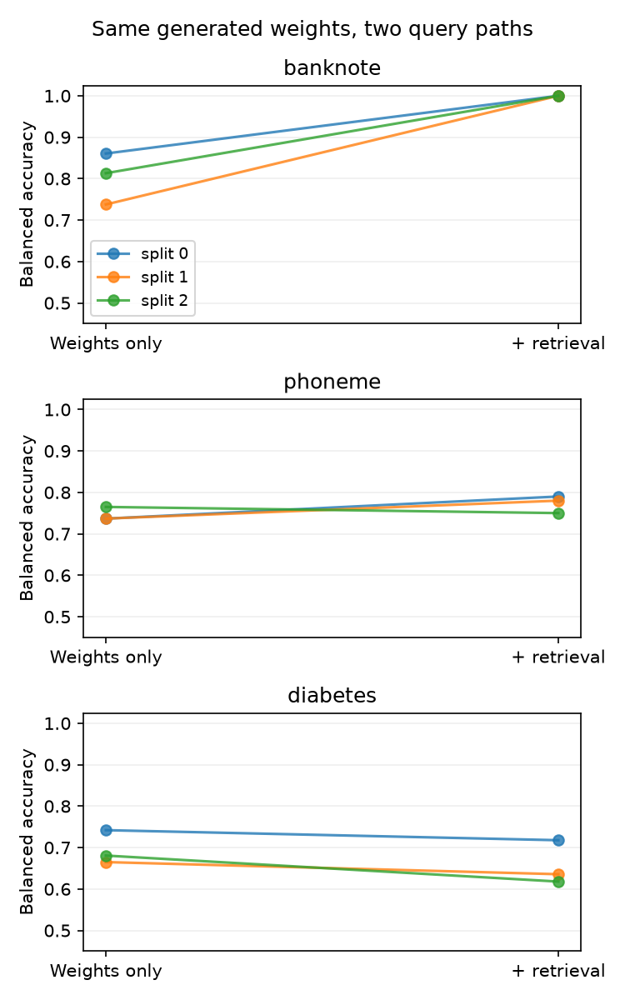

Author reference: paired splits on identical generated predictors. This figure is saved evidence, not output from a blank student kernel.

## Author reference · timing

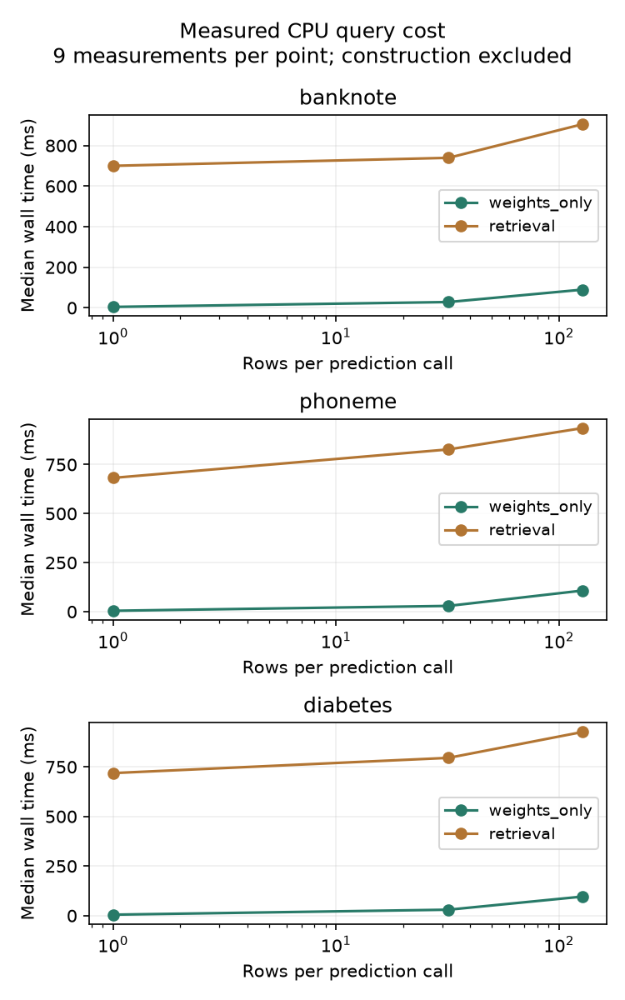

Author reference: call-time medians,3 seeds × 3 repetitions. Construction excluded; hardware/cache policy matters.

| Dataset | Weights only | With retrieval | Paired change |
|---|---:|---:|---:|
| banknote | 80.38 ± 6.20% | 100.00 ± 0.00% | +19.62 pp |
| phoneme | 74.61 ± 1.63% | 77.34 ± 2.09% | +2.73 pp |
| diabetes | 69.59 ± 4.07% | 65.72 ± 5.32% | -3.88 pp |

Mean balanced accuracy ± sample SD over three paired split/model seeds. Paired change is retrieval minus weights-only, in percentage points. SD is not a confidence interval.


All **18 prediction arms / 9,060 query predictions** passed independent row/label, output-layer, retrieval and scalar-score reconstruction. Source-wrapper prediction parity was checked for all nine generated predictors.

Construction took **17.01–20.90s** across nine predictors (median 18.69s). Checkpoint object loading took 0.01s; authentication/download is separate. The banknote seed0 refresh took**20.70s**, changed the generated-state hash, and was not scored as held-out quality.

For banknote, pure predictor arrays require about**103.33MiB**; adding stored raw support/labels gives**103.35MiB**. The shared hypernetwork's parameters occupy about**4.74GiB**; do not confuse the builder with its output. Python/temporary/allocator/peak memory is excluded. The adapter retains support in both arms; discarding it in the pure path is a possible deployment change, not something measured here.

Retrieval raises mean balanced accuracy from 80.38% to 100.00% on banknote and 74.61% to 77.34% on phoneme, but lowers it from 69.59% to 65.72% on diabetes. Phoneme has one negative split effect; diabetes has three. Banknote happens to equal the published 100% number, but the original split/subsample/search identities are still missing: this numerical coincidence is not reproduction.

The quality plot connects the same split across paths. Read each line before trusting a mean: retrieval is an intervention, not a guaranteed improvement. The timing plot excludes construction and shows the release's support recomputation cost. With only these three tables and one checkpoint, no broad model ranking is justified. Nearest-neighbor-only and random-generator controls were not run, so the contribution of meta-training is not isolated. Full per-split log loss and raw timings are in the audit and run report.


## EXIT · Written defense
1. Explain which objects must survive predictor construction in each of the3architectures.
2. Explain the class-head residual and why it does not add to the bias.
3. Interpret the paired split differences without claiming a universal retrieval benefit.
4. Derive the501query and1501query thresholds. Explain batching and possible cache changes.
5. Specify query-label and support-intervention falsifiers. Account for every refit.
6. List missing original Table7 inputs. Why would100% on our banknote split not prove reproduction?

Ask the agent for feedback. Review after 1/7/30 days following completion. Author checks are not learner mastery.


In [ ]:
submission={'status':'PENDING_WRITTEN_DEFENSE','defense':''}
Path('b07a-submission.json').write_text(json.dumps(submission,indent=2))
print(submission['status'])

## NEXT STEP · Original published target
Original HyperFast v1 Table7 banknote:100±0% balanced accuracy;10 mini-test repetitions;300 seconds each. Original split/subsample IDs and selected search trajectories remain missing. The command below is a tested source preflight, not a complete runnable historical evaluator. It refuses execution rather than substituting our course splits. Full meta-training/all-paper/MotherNet/iLTM execution NOT_RUN. No cloud dispatch for an unresolved scientific protocol.

[MotherNet v2 §3](https://arxiv.org/html/2312.08598v2#S3) · [HyperFast v1](https://arxiv.org/html/2402.14335v1) · [iLTM v1 §3](https://arxiv.org/html/2511.15941v1#S3). Source archive contains originals and licenses. HyperFast source is CC BY-NC4.0. The portable package carries code/data/evidence; the checkpoint remains an authenticated external download.


In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    subprocess.run([sys.executable,str(lab/'_reproduce_b07a.py'),'--run'],check=True)
else:
    print('Original paper NOT_RUN:',source['status'])